In [2]:
import pandas as pd
import os
from sqlalchemy import create_engine
username = "postgres"
password = "history123"
host = "localhost"
port = "5432"
database = "urban_cart_db"
connection_string = f'postgresql://{username}:{password}@{host}:{port}/{database}'
engine = create_engine(connection_string)
with engine.connect() as con:
    print("connected!!")

connected!!


In [4]:
orders = pd.read_sql("select * from orders", engine)
customers = pd.read_sql("select * from customers", engine)
order_items = pd.read_sql("select * from order_items", engine)
products = pd.read_sql("select * from products", engine)
shipments = pd.read_sql("select * from shipments", engine)
suppliers = pd.read_sql("select * from suppliers", engine)
warehouses = pd.read_sql("select * from warehouses", engine)

In [5]:
orders.head()

,order_id,customer_id,order_date,warehouse_id,order_status,payment_mode
0,Ord000001,Cust03051,2024-07-02,Wh003,Returned,Upi
1,Ord000002,Cust01810,2022-09-02,Wh013,Shipped,Credit Card
2,Ord000003,Cust02145,2024-02-04,Wh005,Pending,Cod
3,Ord000004,Cust03199,2024-11-27,Wh003,Returned,Debit Card
4,Ord000005,Cust03166,2023-07-04,Wh002,Shipped,Net Banking


In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       4000 non-null   object 
 1   customer_name     3985 non-null   object 
 2   email             3883 non-null   object 
 3   phone             3791 non-null   float64
 4   city              4000 non-null   object 
 5   state             4000 non-null   object 
 6   signup_date       3867 non-null   object 
 7   customer_segment  4000 non-null   object 
dtypes: float64(1), object(7)
memory usage: 250.1+ KB


In [8]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       4000 non-null   object        
 1   customer_name     3985 non-null   object        
 2   email             3883 non-null   object        
 3   phone             3791 non-null   float64       
 4   city              4000 non-null   object        
 5   state             4000 non-null   object        
 6   signup_date       3867 non-null   datetime64[ns]
 7   customer_segment  4000 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 250.1+ KB


In [9]:
shipments["ship_date"] = pd.to_datetime(shipments["ship_date"])
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])
shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7429 entries, 0 to 7428
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   shipment_id      7429 non-null   object        
 1   order_id         7429 non-null   object        
 2   ship_date        7429 non-null   datetime64[ns]
 3   delivery_date    7429 non-null   datetime64[ns]
 4   carrier          7429 non-null   object        
 5   shipping_cost    7288 non-null   float64       
 6   delivery_status  7429 non-null   object        
 7   delivery_days    7429 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 464.4+ KB


In [11]:
products.info()
warehouses.info()
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    586 non-null    object 
 1   product_name  586 non-null    object 
 2   category      586 non-null    object 
 3   sub_category  586 non-null    object 
 4   unit_price    556 non-null    float64
 5   weight_kg     586 non-null    float64
 6   supplier_id   586 non-null    object 
dtypes: float64(2), object(5)
memory usage: 32.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   warehouse_id    18 non-null     object
 1   warehouse_name  18 non-null     object
 2   city            18 non-null     object
 3   state           18 non-null     object
 4   capacity_units  18 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 852.

## Univerate Analysis

 TABLE: customers  | COLUMN: customer_segment
dtypes: object, unique values: 4
customer_segment
Regular    1367
Premium    1333
New         651
Vip         649
Name: count, dtype: int64


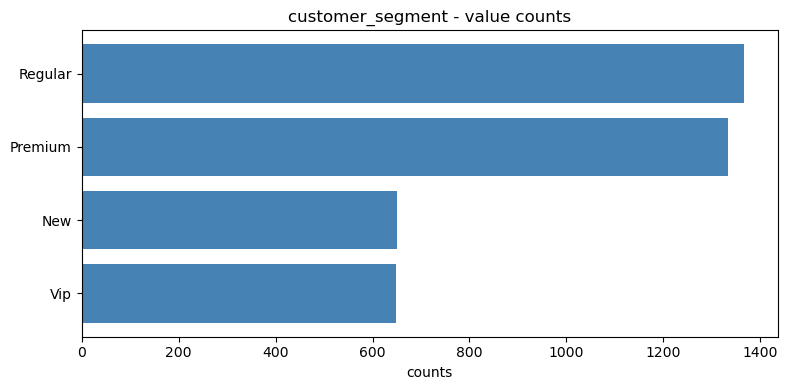

 TABLE: customers  | COLUMN: city
dtypes: object, unique values: 20
city
Ahmedabad    221
Ludhiana     220
Indore       218
Mumbai       210
Chennai      208
Nashik       206
Delhi        206
Lucknow      204
Bengaluru    201
Hyderabad    201
Bhopal       200
Agra         200
Jaipur       198
Vadodara     196
Kolkata      191
Nagpur       189
Pune         188
Patna        186
Kanpur       179
Surat        178
Name: count, dtype: int64


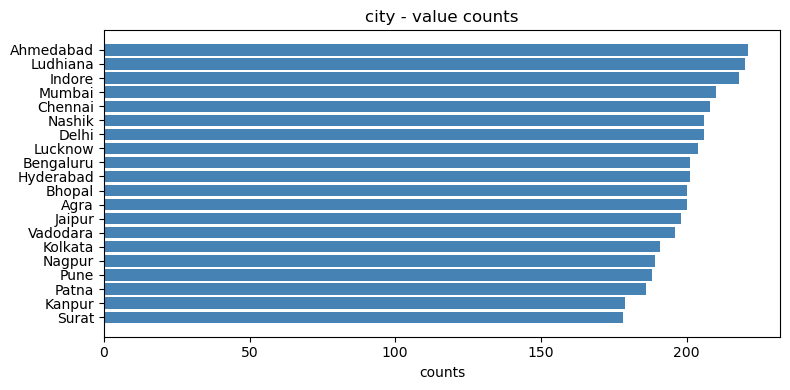

 TABLE: customers  | COLUMN: state
dtypes: object, unique values: 12
state
Maharashtra       793
Gujarat           595
Uttar Pradesh     583
Madhya Pradesh    418
Punjab            220
Tamil Nadu        208
Delhi             206
Karnataka         201
Telangana         201
Rajasthan         198
West Bengal       191
Bihar             186
Name: count, dtype: int64


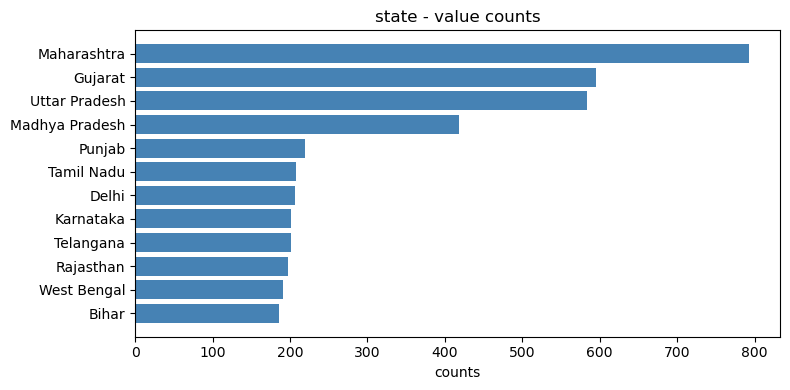

 TABLE: products  | COLUMN: unit_price
dtypes: float64, unique values: 556
count      556.000000
mean      7895.217392
std      12401.129110
min         25.650000
25%       1121.885000
50%       2924.460000
75%       8695.507500
max      59683.470000
Name: unit_price, dtype: float64


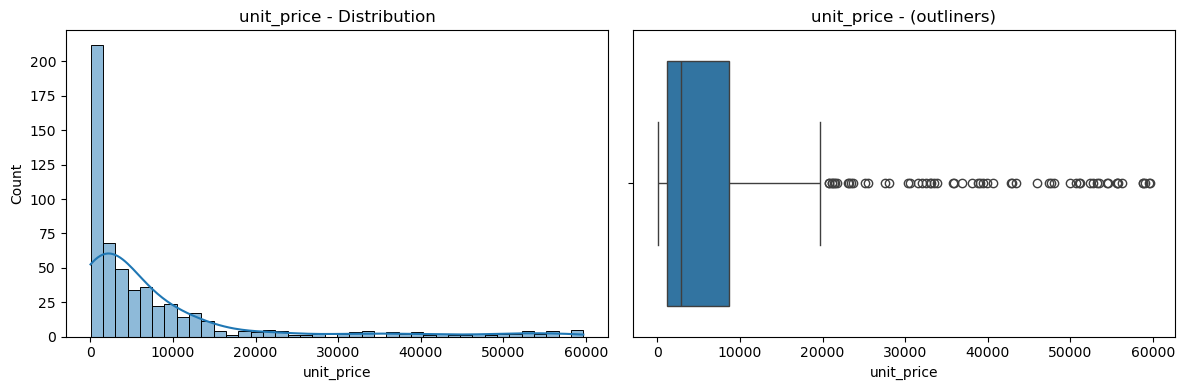

 TABLE: products  | COLUMN: category
dtypes: object, unique values: 6
category
Home & Kitchen    111
Grocery           102
Sports            100
Electronics        97
Books              89
Fashion            87
Name: count, dtype: int64


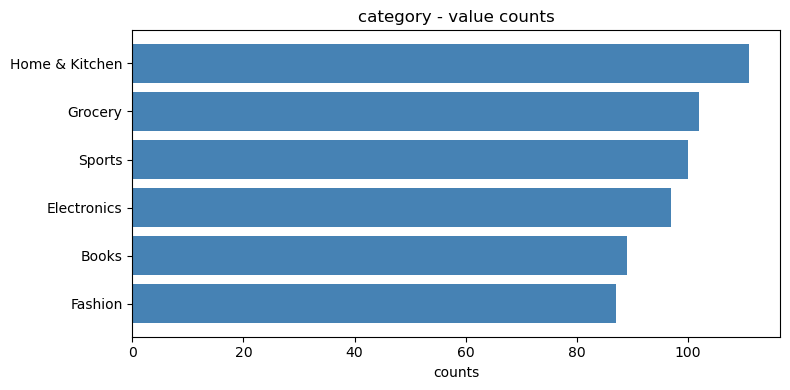

 TABLE: orders  | COLUMN: order_status
dtypes: object, unique values: 6
order_status
Shipped       1466
Processing    1438
Cancelled     1436
Pending       1427
Delivered     1411
Returned      1401
Name: count, dtype: int64


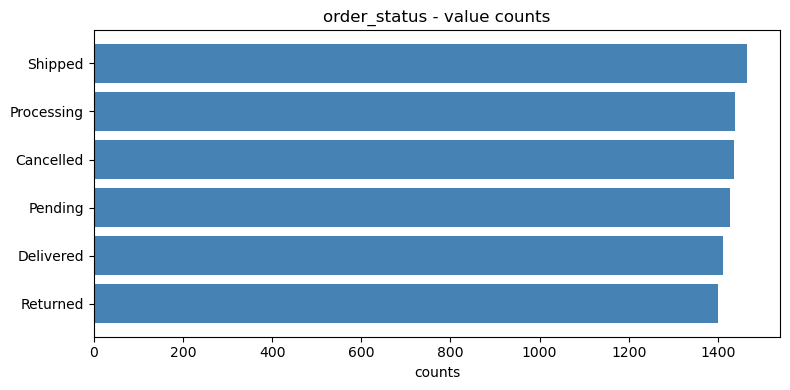

 TABLE: order_items  | COLUMN: quantity
dtypes: float64, unique values: 7
quantity
1.0      5224
2.0      3485
4.0      1737
10.0     1725
3.0      1723
5.0      1701
500.0      98
Name: count, dtype: int64


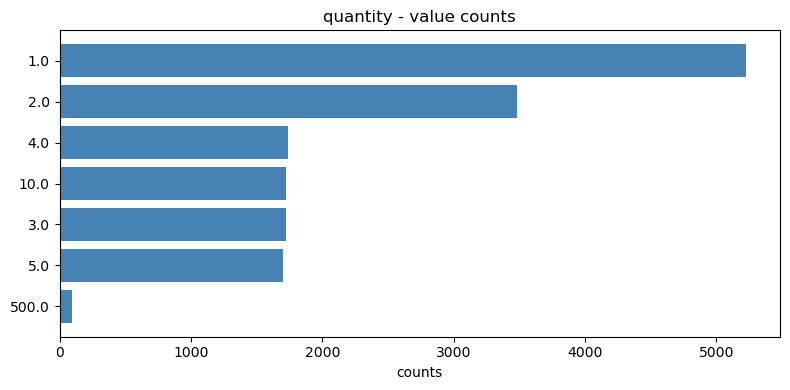

 TABLE: order_items  | COLUMN: discount_pct
dtypes: int64, unique values: 6
discount_pct
0     5893
10    1980
15    1979
20    1967
25    1966
5     1908
Name: count, dtype: int64


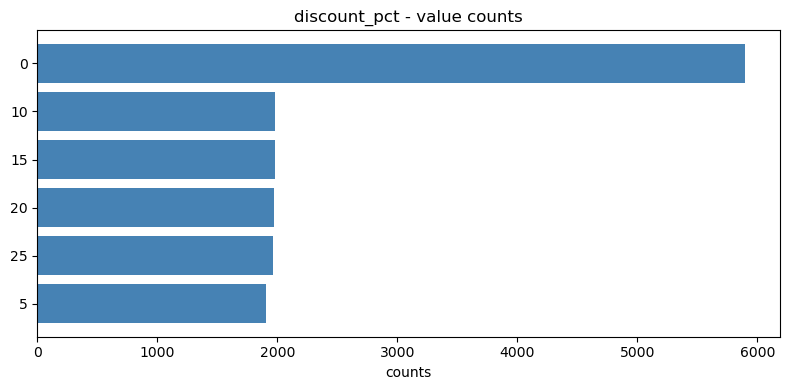

 TABLE: shipments  | COLUMN: shipping_cost
dtypes: float64, unique values: 6986
count    7288.000000
mean      467.243134
std       251.560179
min        30.060000
25%       250.015000
50%       465.605000
75%       682.167500
max       899.950000
Name: shipping_cost, dtype: float64


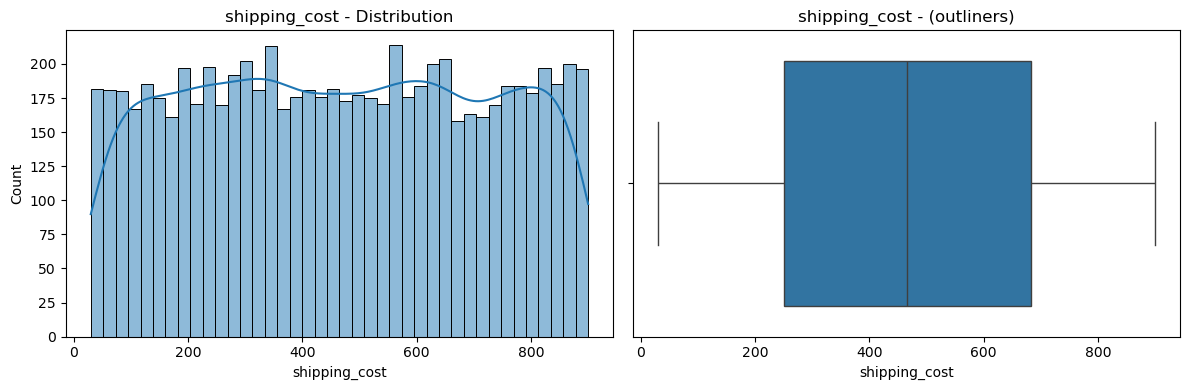

 TABLE: shipments  | COLUMN: carrier
dtypes: object, unique values: 7
carrier
Delhivery     1079
Fedex         1076
Bluedart      1074
Indiapost     1073
Dtdc          1053
Xpressbees    1042
Ekart         1032
Name: count, dtype: int64


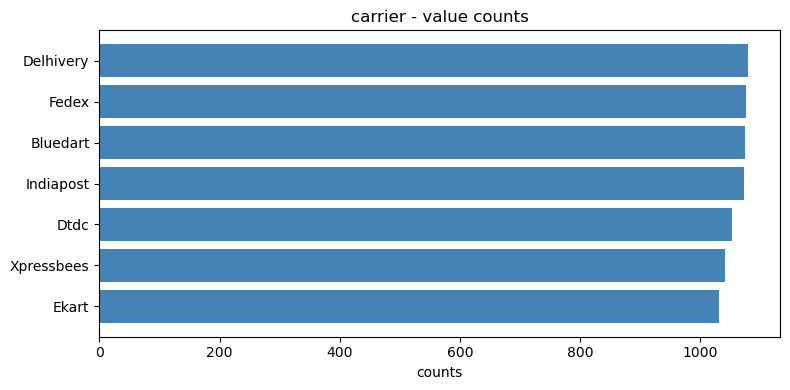

 TABLE: shipments  | COLUMN: delivery_status
dtypes: object, unique values: 5
delivery_status
Delivered             1516
Returned To Origin    1512
In Transit            1490
Lost                  1465
Delayed               1446
Name: count, dtype: int64


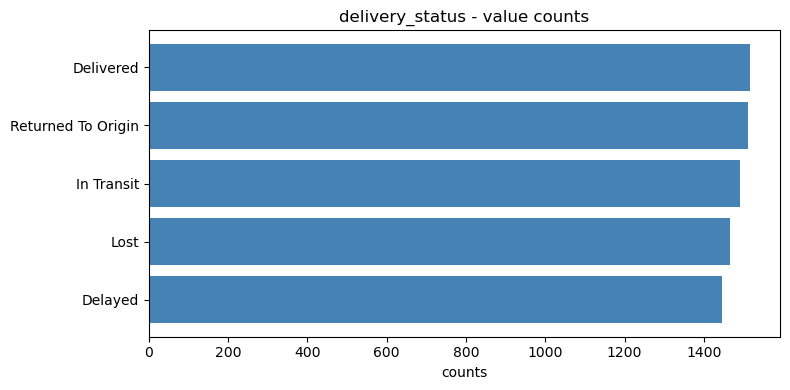

 TABLE: suppliers  | COLUMN: country
dtypes: object, unique values: 8
country
China         13
Bangladesh     9
Vietnam        8
Germany        8
India          7
Usa            7
Indonesia      6
Sri Lanka      2
Name: count, dtype: int64


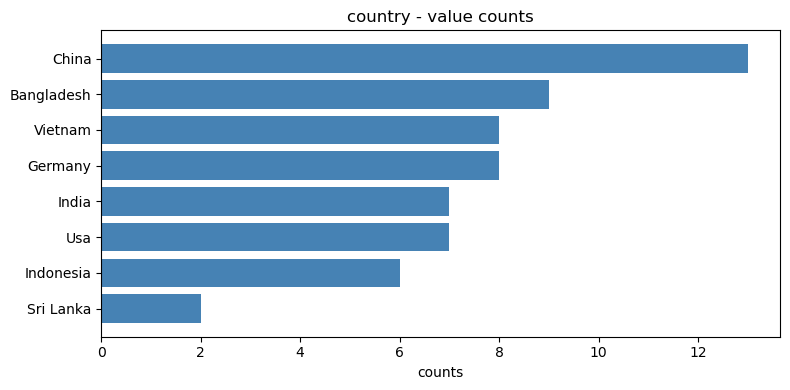

 TABLE: suppliers  | COLUMN: lead_time_days
dtypes: int64, unique values: 11
lead_time_days
 3     8
 15    7
-5     7
 7     7
 10    6
 25    6
 30    6
 14    4
 5     4
 21    3
 18    2
Name: count, dtype: int64


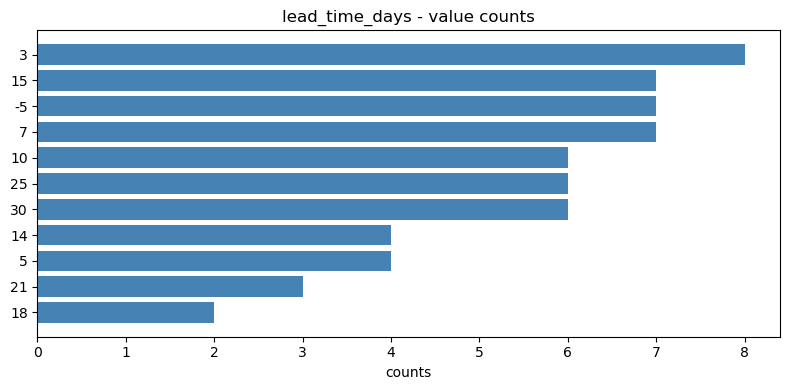

 TABLE: suppliers  | COLUMN: reliability_score
dtypes: float64, unique values: 54
count    58.000000
mean     80.894828
std      11.446189
min      60.100000
25%      71.025000
50%      80.850000
75%      90.550000
max      98.900000
Name: reliability_score, dtype: float64


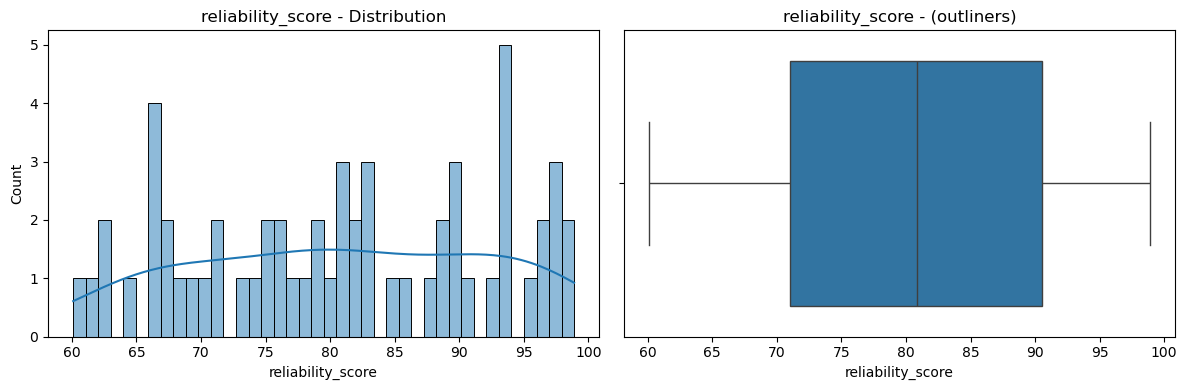

In [12]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
def univariate_analysis(df, col, table_name="", cat_threshold=20):
    series = df[col].dropna()
    n_unique = series.nunique()
    is_numeric = pd.api.types.is_numeric_dtype(series)

    print(f"{"="*60}")
    print(f" TABLE: {table_name}  | COLUMN: {col}")
    print(f"{"="*60}")
    print(f"dtypes: {series.dtypes}, unique values: {n_unique}")


    if is_numeric and n_unique > cat_threshold:

        print(series.describe())

        fig, axes=plt.subplots(1, 2, figsize=(12,4))
        sns.histplot(series, bins=40, ax=axes[0], kde=True)
        axes[0].set_title(f"{col} - Distribution")
        sns.boxplot(x=series, ax=axes[1])
        axes[1].set_title(f"{col} - (outliners)")
        plt.tight_layout()
        plt.show()

    else:

        count = series.value_counts().head(20)
        print(count) 
        plt.figure(figsize=(8,4))  
        plt.barh(count.index.astype(str), count.values , color = "steelblue")
        plt.title(f"{col} - value counts")
        plt.xlabel("counts")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()


tables = {
    "customers": customers,
    "products": products,
    "orders": orders,
    "order_items": order_items,
    "shipments": shipments,
    "suppliers": suppliers
}

columns_to_ana = {
    "customers": ["customer_segment" , "city" , "state"],
    "products": ["unit_price", "category"],
    "orders": ["order_status"],
    "order_items": ["quantity", "discount_pct"],
    "shipments": ["shipping_cost", "carrier", "delivery_status"],
    "suppliers": ["country", "lead_time_days", "reliability_score"]
}

for table_name, cols in columns_to_ana.items():
    df= tables[table_name]
    for col in cols:
        univariate_analysis(df, col, table_name=table_name)
        

### Q1 Relation between customer segments and order values

In [15]:
order_item_value = order_items.merge(products[["product_id", "unit_price"]], on="product_id") 
order_item_value["line_value"] = (
    order_item_value["quantity"]*order_item_value["unit_price"]*(1- order_item_value["discount_pct"]/100) 
)
order_value = order_item_value.groupby("order_id")["line_value"].sum().reset_index()
order_value.rename(columns={"line_value":"order_value"}, inplace=True) 

orders_seg = orders.merge(order_value, on="order_id").merge(
    customers[["customer_id", "customer_segment"]], on="customer_id")

seg_summary  = orders_seg.groupby("customer_segment")["order_value"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
print(seg_summary)
med = orders_seg.groupby("customer_segment")["order_value"].median().sort_values(ascending=False)


                  count          mean       median
customer_segment                                  
New                1257  83307.239562  14763.12000
Premium            2669  79582.101782  15714.36900
Vip                1302  72411.117038  15851.96250
Regular            2810  58120.669590  15162.27425


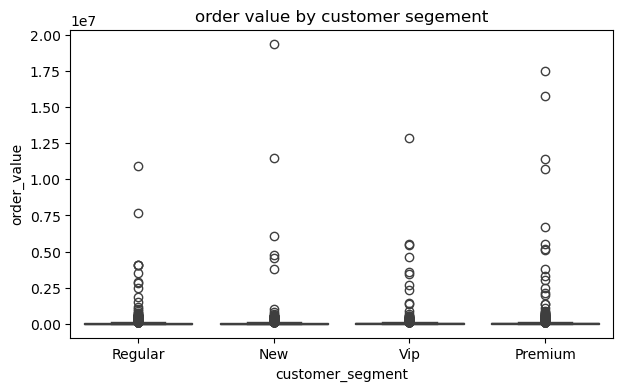

In [16]:
plt.figure(figsize=(7,4))
sns.boxplot(data=orders_seg, x= "customer_segment", y="order_value")
plt.title("order value by customer segement")
plt.show()

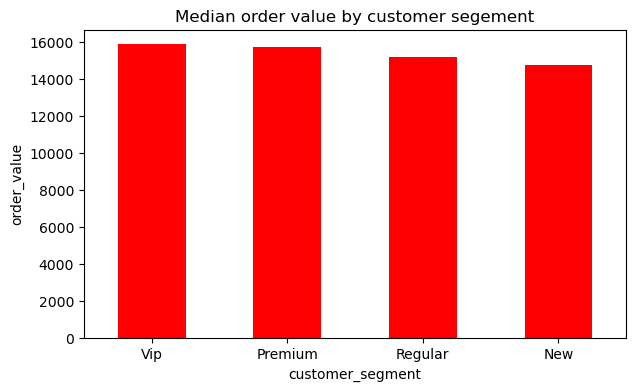

In [17]:
plt.figure(figsize=(7,4))
med.plot(kind="bar", color="red")
plt.title("Median order value by customer segement")
plt.ylabel("order_value")
plt.xticks(rotation=0)
plt.show()

### Q2 Shipping days Vs carrier

In [20]:
carrier_summary = shipments.groupby("carrier")["shipping_cost"].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False).round(2)
carrier_summary

,count,mean,median,std
carrier,,,,
Bluedart,1046,471.53,461.98,255.15
Xpressbees,1022,470.50,473.53,249.82
Fedex,1062,470.20,471.46,250.40
Indiapost,1056,466.92,463.30,250.05
Ekart,1014,465.65,462.98,259.58
Dtdc,1037,463.61,470.72,250.43
Delhivery,1051,462.27,458.28,246.07


In [21]:
shipments.head()

,shipment_id,order_id,ship_date,delivery_date,carrier,shipping_cost,delivery_status,delivery_days
0,Shp000002,Ord000002,2022-09-05,2022-09-06,Indiapost,413.53,Delivered,1
1,Shp000003,Ord000003,2024-04-04,2024-04-19,Dtdc,552.47,Delivered,15
2,Shp000004,Ord000004,2024-11-29,2024-11-30,Dtdc,66.02,Delivered,1
3,Shp000005,Ord000005,2023-07-04,2023-07-10,Dtdc,82.97,Returned To Origin,6
4,Shp000006,Ord000006,2023-04-09,2023-04-11,Bluedart,801.61,In Transit,2


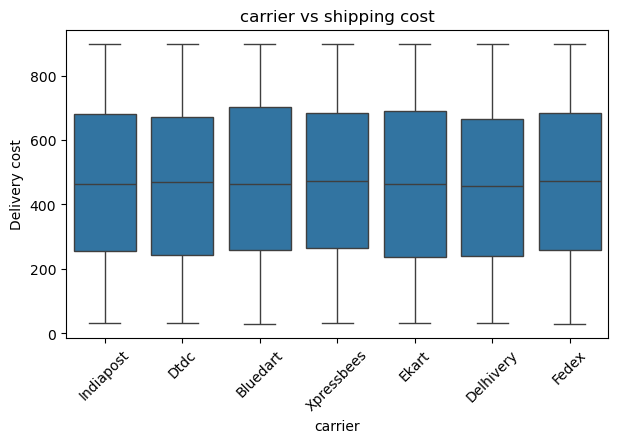

In [25]:
plt.figure(figsize=(7,4))
sns.boxplot(data=shipments, x="carrier", y="shipping_cost")
plt.xticks(rotation=45)
plt.title("carrier vs shipping cost")
plt.ylabel("Delivery cost")
plt.show()

## Q3 Shipping Cost Vs carrier

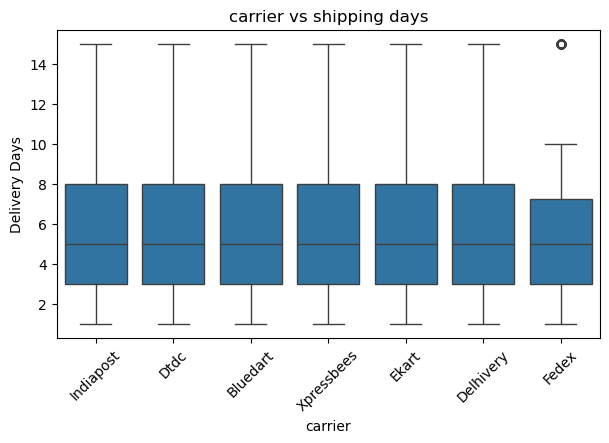

In [26]:
plt.figure(figsize=(7,4))
sns.boxplot(data=shipments, x="carrier", y="delivery_days")
plt.xticks(rotation=45)
plt.title("carrier vs shipping days")
plt.ylabel("Delivery Days")
plt.show()

### Q3 Delivery delay vs warehouse

In [28]:
warehouses.head()

,warehouse_id,warehouse_name,city,state,capacity_units
0,Wh001,Nagpur Fulfilment Center,Nagpur,Maharashtra,25000
1,Wh002,Indore Fulfilment Center,Indore,Madhya Pradesh,20000
2,Wh003,Lucknow Fulfilment Center,Lucknow,Uttar Pradesh,15000
3,Wh004,Kanpur Fulfilment Center,Kanpur,Uttar Pradesh,20000
4,Wh005,Ahmedabad Fulfilment Center,Ahmedabad,Gujarat,25000


In [29]:
orders.head()

,order_id,customer_id,order_date,warehouse_id,order_status,payment_mode
0,Ord000001,Cust03051,2024-07-02,Wh003,Returned,Upi
1,Ord000002,Cust01810,2022-09-02,Wh013,Shipped,Credit Card
2,Ord000003,Cust02145,2024-02-04,Wh005,Pending,Cod
3,Ord000004,Cust03199,2024-11-27,Wh003,Returned,Debit Card
4,Ord000005,Cust03166,2023-07-04,Wh002,Shipped,Net Banking


In [30]:
# merging columns from sshipments, orders, wwarehouses
ship_full = (
    shipments.merge(orders[["order_id", "warehouse_id", "customer_id"]], on="order_id")
    .merge(warehouses[["warehouse_id", "city"]].rename(columns={"city": "warehouse_city"}), on ="warehouse_id")
    .merge(customers[["customer_id", "city"]].rename(columns={"city": "customer_city"}), on = "customer_id")
)

ship_full["same_city"] = ship_full["warehouse_city"] == ship_full["customer_city"]
ship_full["delivery_type"] = ship_full["same_city"].map({True: "local", False: "cross_city"})
ship_full.head()
    
           

,shipment_id,order_id,ship_date,delivery_date,carrier,shipping_cost,delivery_status,delivery_days,warehouse_id,customer_id,warehouse_city,customer_city,same_city,delivery_type
0,Shp000002,Ord000002,2022-09-05,2022-09-06,Indiapost,413.53,Delivered,1,Wh013,Cust01810,Mumbai,Nashik,False,cross_city
1,Shp000003,Ord000003,2024-04-04,2024-04-19,Dtdc,552.47,Delivered,15,Wh005,Cust02145,Ahmedabad,Lucknow,False,cross_city
2,Shp000004,Ord000004,2024-11-29,2024-11-30,Dtdc,66.02,Delivered,1,Wh003,Cust03199,Lucknow,Indore,False,cross_city
3,Shp000005,Ord000005,2023-07-04,2023-07-10,Dtdc,82.97,Returned To Origin,6,Wh002,Cust03166,Indore,Surat,False,cross_city
4,Shp000006,Ord000006,2023-04-09,2023-04-11,Bluedart,801.61,In Transit,2,Wh011,Cust02101,Delhi,Mumbai,False,cross_city


              count  mean  median
warehouse_id                     
Wh001           369  5.71     4.0
Wh002           372  5.68     5.0
Wh003           398  5.91     5.0
Wh004           372  5.81     5.0
Wh005           400  6.02     5.0
Wh006           387  5.60     5.0
Wh007           407  5.76     5.0
Wh008           383  5.74     5.0
Wh009           410  6.03     5.0
Wh010           359  5.89     5.0
Wh011           402  5.73     5.0
Wh012           380  5.91     5.0
Wh013           389  5.80     5.0
Wh014           398  6.05     6.0
Wh015           408  5.67     5.0
Wh016           441  5.69     5.0
Wh017           405  5.83     5.0
Wh018           397  6.00     5.0


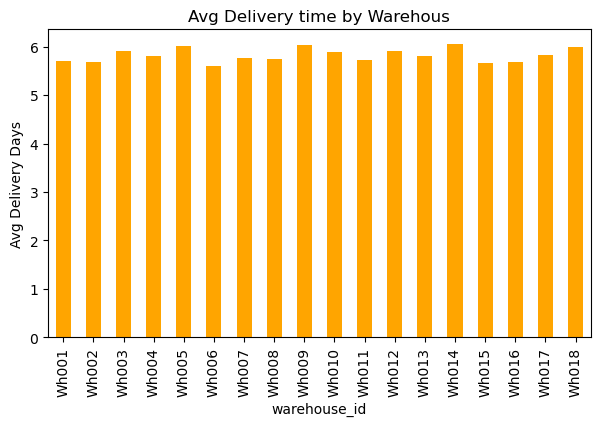

In [32]:
warehouse_delivery = ship_full.groupby("warehouse_id")["delivery_days"].agg(["count", "mean", "median"]).round(2)
print(warehouse_delivery)

plt.figure(figsize=(7,4))
warehouse_delivery["mean"].plot(kind="bar", color="orange")
plt.title("Avg Delivery time by Warehous")
plt.ylabel("Avg Delivery Days")
plt.show()

## Q4 Delivery Time Local Vs Cross city

In [33]:
distance_delivery = ship_full.groupby("delivery_type")["delivery_days"].agg(["count", "mean", "median"])
distance_delivery

,count,mean,median
delivery_type,,,
cross_city,6712,5.865465,5.0
local,365,5.057534,4.0


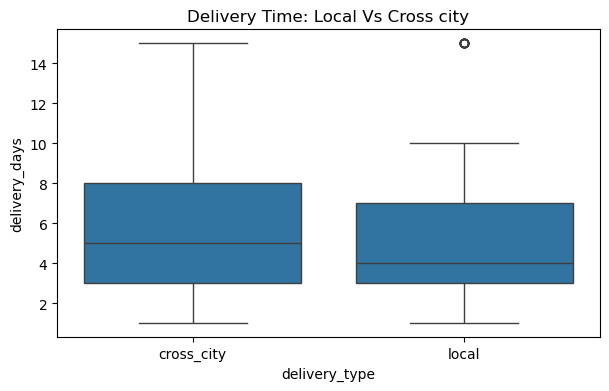

In [34]:
plt.figure(figsize=(7,4))
sns.boxplot(data=ship_full, x="delivery_type", y="delivery_days")
plt.title("Delivery Time: Local Vs Cross city")
plt.show()

## Q5 Category vs. average discount given.

In [38]:
order_items.head()

,order_item_id,order_id,product_id,quantity,discount_pct
0,Oi0000001,Ord000001,Prod00419,5.0,0
1,Oi0000002,Ord000002,Prod00090,10.0,0
2,Oi0000003,Ord000002,Prod00503,10.0,0
3,Oi0000004,Ord000002,Prod00018,5.0,0
4,Oi0000005,Ord000002,Prod00591,5.0,20


In [39]:
products.head()

,product_id,product_name,category,sub_category,unit_price,weight_kg,supplier_id
0,Prod00001,Team Sports Item 1,Sports,Team Sports,6735.55,13.88,Sup0013
1,Prod00002,Bags Item 2,Fashion,Bags,2149.16,8.09,Sup0029
2,Prod00003,Non-Fiction Item 3,Books,Non-Fiction,1908.75,7.79,Sup0052
3,Prod00004,Dairy Item 4,Grocery,Dairy,952.05,6.14,Sup0042
4,Prod00005,Cameras Item 5,Electronics,Cameras,13521.05,3.38,Sup0030


                count  mean  median
category                           
Books            2431  9.21    10.0
Electronics      2560  9.45    10.0
Fashion          2252  9.47    10.0
Grocery          2693  9.31     5.0
Home & Kitchen   3049  9.47    10.0
Sports           2708  9.49    10.0


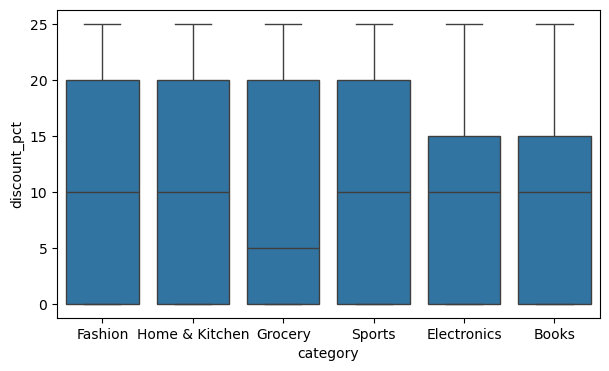

In [41]:
oi_cat = order_items.merge(products[["product_id", "category"]], on="product_id")

category_dis = (
    oi_cat.groupby("category")["discount_pct"].agg(["count", "mean", "median"]).round(2)
)

print(category_dis)

plt.figure(figsize=(7,4))
sns.boxplot(data=oi_cat, x= "category", y="discount_pct")
plt.show()

## Time Series Analysis

### Q1 Number of monthly orders

In [42]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8579 entries, 0 to 8578
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      8579 non-null   object
 1   customer_id   8579 non-null   object
 2   order_date    8579 non-null   object
 3   warehouse_id  8579 non-null   object
 4   order_status  8579 non-null   object
 5   payment_mode  8579 non-null   object
dtypes: object(6)
memory usage: 402.3+ KB


In [43]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [45]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8579 entries, 0 to 8578
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      8579 non-null   object        
 1   customer_id   8579 non-null   object        
 2   order_date    8579 non-null   datetime64[ns]
 3   warehouse_id  8579 non-null   object        
 4   order_status  8579 non-null   object        
 5   payment_mode  8579 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 402.3+ KB


In [48]:
orders["order_month"] = orders["order_date"].dt.to_period("M")
orders["order_year"] = orders["order_date"].dt.to_period("Y")

monthly_orders = orders.groupby("order_month").size()
yearly_orders = orders.groupby("order_year").size()

print(yearly_orders)
print(monthly_orders)

order_year
2022    2917
2023    2789
2024    2873
Freq: Y-DEC, dtype: int64
order_month
2022-01    227
2022-02    207
2022-03    232
2022-04    235
2022-05    253
2022-06    243
2022-07    261
2022-08    244
2022-09    244
2022-10    275
2022-11    236
2022-12    260
2023-01    219
2023-02    233
2023-03    250
2023-04    217
2023-05    253
2023-06    234
2023-07    251
2023-08    240
2023-09    223
2023-10    218
2023-11    207
2023-12    244
2024-01    238
2024-02    221
2024-03    250
2024-04    240
2024-05    259
2024-06    226
2024-07    199
2024-08    256
2024-09    247
2024-10    255
2024-11    248
2024-12    234
Freq: M, dtype: int64


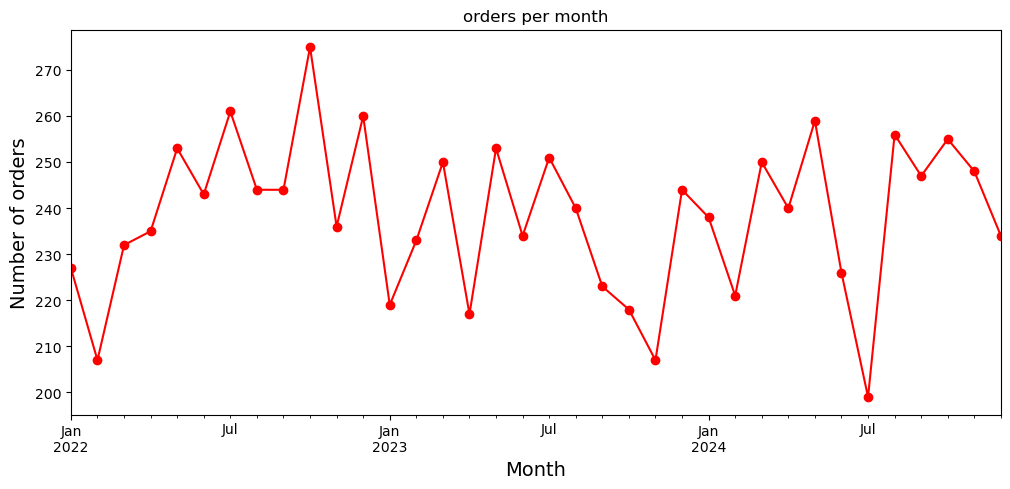

In [49]:
monthly_orders.plot(kind='line', marker='o', figsize=(12,5), color="red")
plt.title("orders per month")
plt.xlabel("Month", fontsize='14')
plt.ylabel("Number of orders", fontsize="14")
plt.show()

### Q2 Revenue Per Month

In [52]:
order_items.head()

,order_item_id,order_id,product_id,quantity,discount_pct
0,Oi0000001,Ord000001,Prod00419,5.0,0
1,Oi0000002,Ord000002,Prod00090,10.0,0
2,Oi0000003,Ord000002,Prod00503,10.0,0
3,Oi0000004,Ord000002,Prod00018,5.0,0
4,Oi0000005,Ord000002,Prod00591,5.0,20


In [53]:
products.head()

,product_id,product_name,category,sub_category,unit_price,weight_kg,supplier_id
0,Prod00001,Team Sports Item 1,Sports,Team Sports,6735.55,13.88,Sup0013
1,Prod00002,Bags Item 2,Fashion,Bags,2149.16,8.09,Sup0029
2,Prod00003,Non-Fiction Item 3,Books,Non-Fiction,1908.75,7.79,Sup0052
3,Prod00004,Dairy Item 4,Grocery,Dairy,952.05,6.14,Sup0042
4,Prod00005,Cameras Item 5,Electronics,Cameras,13521.05,3.38,Sup0030


In [54]:
order_rev = order_items.merge(products[["product_id", "unit_price"]], on="product_id")
order_rev["line_value"] = order_rev["quantity"]*order_rev["unit_price"]*(1-order_rev["discount_pct"]/100)
o_revenue = orders.merge(
    order_rev.groupby("order_id")["line_value"].sum().reset_index().rename(columns={"line_value": "order_value"}),
on="order_id")
o_revenue.head()

,order_id,customer_id,order_date,warehouse_id,order_status,payment_mode,order_month,order_year,order_value
0,Ord000001,Cust03051,2024-07-02,Wh003,Returned,Upi,2024-07,2024,7416.6000
1,Ord000002,Cust01810,2022-09-02,Wh013,Shipped,Credit Card,2022-09,2022,161920.7900
2,Ord000003,Cust02145,2024-02-04,Wh005,Pending,Cod,2024-02,2024,3478.9395
3,Ord000004,Cust03199,2024-11-27,Wh003,Returned,Debit Card,2024-11,2024,15089.5840
4,Ord000005,Cust03166,2023-07-04,Wh002,Shipped,Net Banking,2023-07,2023,7570.0400


In [55]:
def format_currency(x):
    if x >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    elif x>= 1_000:
        return f"${x/1_000:.2f}K"
    else:
        return f"${x:.2f}"

In [56]:
monthly_revenue = o_revenue.groupby("order_month")["order_value"].sum().round()
monthly_revenue.apply(format_currency)

order_month
2022-01     $8.33M
2022-02    $10.91M
2022-03    $11.65M
2022-04    $12.59M
2022-05    $11.31M
2022-06    $11.79M
2022-07    $26.61M
2022-08    $12.50M
2022-09    $16.43M
2022-10    $16.25M
2022-11    $15.25M
2022-12    $21.81M
2023-01    $10.97M
2023-02    $13.72M
2023-03    $16.57M
2023-04     $9.73M
2023-05    $15.35M
2023-06     $9.92M
2023-07    $22.97M
2023-08     $9.67M
2023-09     $9.17M
2023-10     $9.78M
2023-11    $11.86M
2023-12    $23.12M
2024-01     $9.36M
2024-02    $20.44M
2024-03     $9.75M
2024-04     $8.88M
2024-05    $35.09M
2024-06    $17.20M
2024-07    $32.14M
2024-08     $9.91M
2024-09    $36.07M
2024-10    $23.66M
2024-11    $22.30M
2024-12    $11.65M
Freq: M, Name: order_value, dtype: object

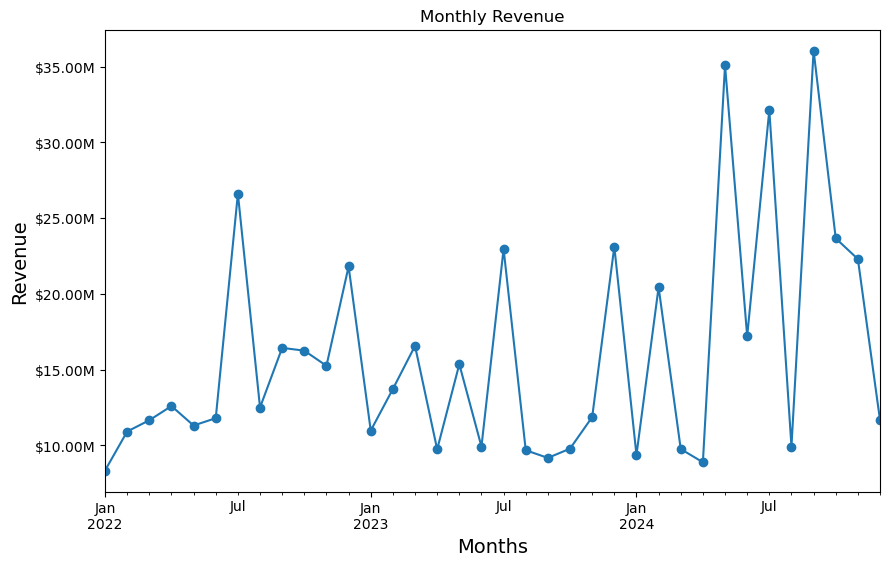

In [57]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10,6))          
monthly_revenue.plot(kind="line", marker="o", ax=ax)   
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: format_currency(x)))

plt.title("Monthly Revenue")
plt.xlabel("Months", fontsize=14)
plt.ylabel("Revenue", fontsize=14)
plt.show()

### Q6 Avg Delivery Time according to months

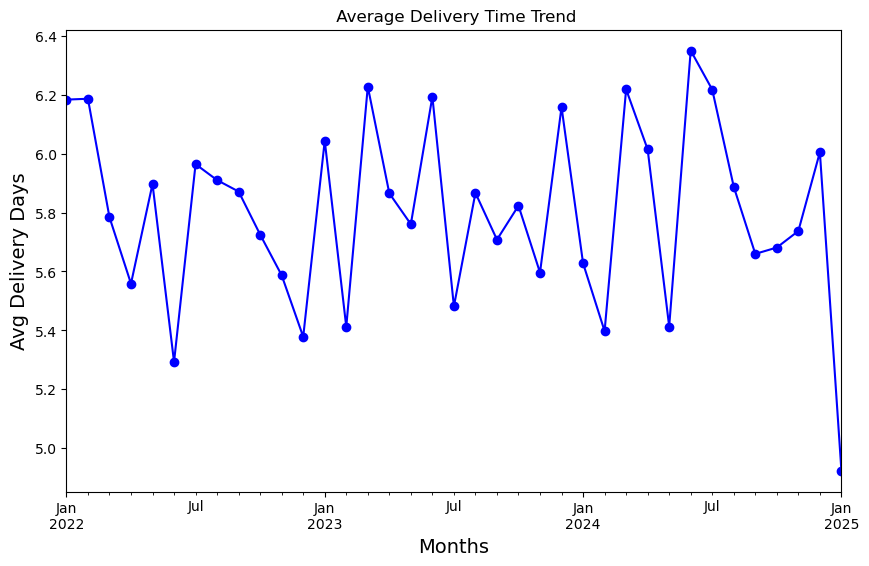

In [58]:
shipments["ship_month"] = shipments["ship_date"].dt.to_period("M")
monthly_delivery = shipments.groupby("ship_month")["delivery_days"].mean()

fig, ax = plt.subplots(figsize=(10,6))
monthly_delivery.plot(kind="line", marker="o", ax=ax, color="blue")
plt.title(" Average Delivery Time Trend")
plt.xlabel("Months", fontsize="14")
plt.ylabel("Avg Delivery Days", fontsize="14")
plt.show()

### Check for outliners if any

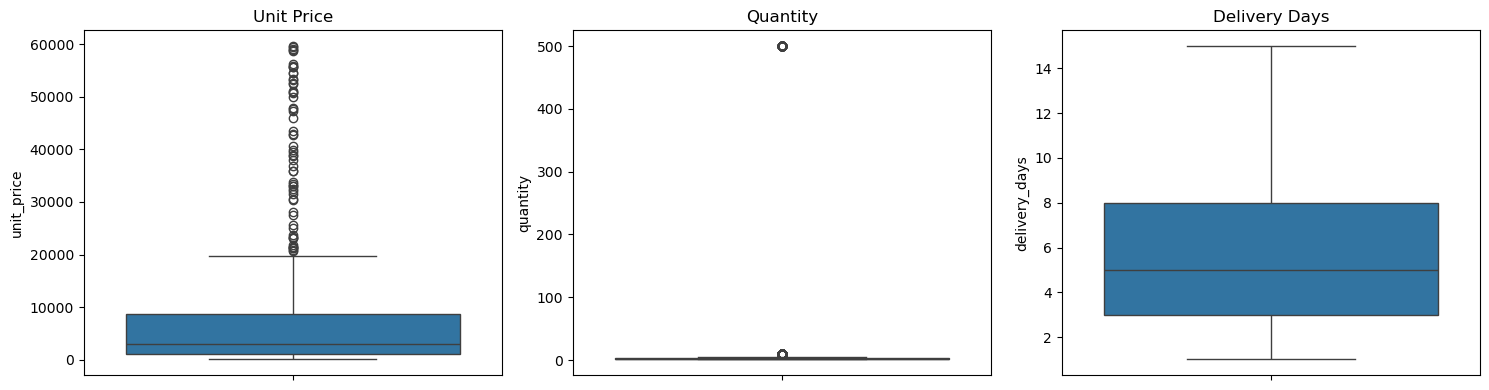

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=products["unit_price"], ax=axes[0]); axes[0].set_title("Unit Price")
sns.boxplot(y=order_items["quantity"], ax=axes[1]); axes[1].set_title("Quantity")
sns.boxplot(y=shipments["delivery_days"], ax=axes[2]); axes[2].set_title("Delivery Days")
plt.tight_layout()
plt.show()

## Q7 Correlation Heat Map between quantity, unit price and dicount given

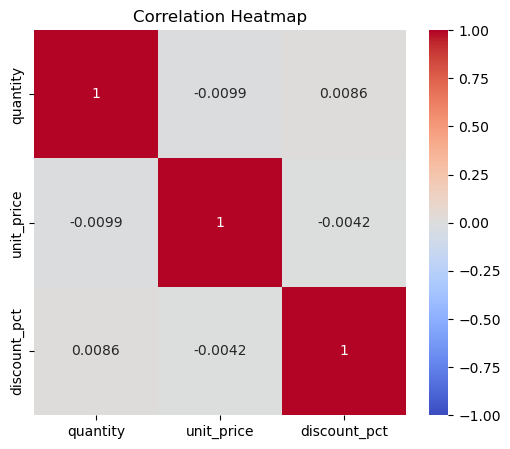

In [62]:
merged = order_items.merge(products[["product_id","unit_price"]], on="product_id")
corr_cols = merged[["quantity", "unit_price", "discount_pct"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_cols, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

In [63]:
from pathlib import Path

output_folder = Path(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned")
output_folder.mkdir(exist_ok=True)

customers.to_csv(output_folder / "customers_cleaned.csv", index=False)
orders.to_csv(output_folder / "orders_cleaned.csv", index=False)
order_items.to_csv(output_folder / "order_items_cleaned.csv", index=False)
products.to_csv(output_folder / "products_cleaned.csv", index=False)
shipments.to_csv(output_folder / "shipments_cleaned.csv", index=False)
warehouses.to_csv(output_folder / "warehouses_cleaned.csv", index=False)
suppliers.to_csv(output_folder / "suppliers_cleaned.csv", index=False)

In [66]:
from sqlalchemy import create_engine
username = "postgres"
password = "history123"
host = "localhost"
port = "5432"
database = "urban_cart_db"
connection_string = f'postgresql://{username}:{password}@{host}:{port}/{database}'
engine = create_engine(connection_string)
with engine.connect() as con:
    print("connected!!")

connected!!


In [72]:
alter_sql = """
ALTER TABLE orders ADD COLUMN IF NOT EXISTS order_month VARCHAR(7);
ALTER TABLE orders ADD COLUMN IF NOT EXISTS order_year INT;

ALTER TABLE shipments ADD COLUMN IF NOT EXISTS delivery_days INT;
ALTER TABLE shipments ADD COLUMN IF NOT EXISTS ship_month VARCHAR(7);
"""

with engine.connect() as conn:
    for statement in alter_sql.strip().split(";"):
        if statement.strip():
            conn.execute(text(statement))
    conn.commit()

print("Columns added.")

Columns added.


In [73]:
from sqlalchemy import text

truncate_sql = "TRUNCATE TABLE shipments, order_items, orders, products, suppliers, warehouses, customers RESTART IDENTITY CASCADE;"
with engine.connect() as conn:
    conn.execute(text(truncate_sql))
    conn.commit()

In [74]:
def load_to_db(file_path, table_name, engine):
    try:
        df = pd.read_csv(file_path, parse_dates=True)
        df.to_sql(name=table_name, con=engine, if_exists="append", index=False)
        print(f"{table_name} loaded: {len(df)} rows")
    except Exception as e:
        print(f"{table_name}: ERROR - {e}")

In [75]:
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\customers_cleaned.csv", "customers", engine)
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\order_items_cleaned.csv", "order_items", engine)
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\orders_cleaned.csv", "orders", engine)
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\products_cleaned.csv", "products", engine)
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\shipments_cleaned.csv", "shipments", engine)
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\suppliers_cleaned.csv", "suppliers", engine)
load_to_db(r"C:\Users\RUCHIR\anaconda_projects\New_project\data_cleaned\warehouses_cleaned.csv", "warehouses", engine)

customers loaded: 4000 rows
order_items loaded: 15693 rows
orders loaded: 8579 rows
products loaded: 586 rows
shipments loaded: 7429 rows
suppliers loaded: 60 rows
warehouses loaded: 18 rows
